<a href="https://colab.research.google.com/github/paulosrl/NotebooksGoogleColab/blob/main/Arvore%20de%20Decis%C3%A3o%20e%20Naive%20Bayes%20-%20ALUNOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 4 — Comparação entre Árvore de Decisão e Naive Bayes
### Classificação do Tipo de Manutenção Industrial (Preventiva · Preditiva · Corretiva)

**Disciplina:** Inteligência Computacional Aplicada à Engenharia de Produção

**Professor:** Paulo Sergio Rodrigues Lima

**Curso:** Engenharia de Produção — UEPA

**Equipe:**
* Bernardo Brasil Vasconcellos Sobral
* Cauã Costa da Silva
* Lucas Ryu  Morotomi Pereira
* Victor Gabriel Alves dos Santos
* Willyam Cristian Souza Gonçalves

**Data:** Junho / 2026

---

> ### ▶️ Como executar:
> 1. No menu lateral esquerdo, clique no ícone de **pasta** 📁 e faça **upload** do arquivo `dados_manutencao.csv`.
> 2. No menu, vá em **Ambiente de execução → Executar tudo** (`Ctrl+F9`).
> 3. Cada seção roda de forma independente e imprime/plota o seu próprio resultado.
>
> Caso o arquivo não seja encontrado, a própria célula de carregamento abrirá um botão de upload.

## 1. Contexto, Objetivo e Metodologia

### Contexto
Na Engenharia de Produção, prever corretamente o **tipo de manutenção** que um equipamento exige é
essencial para **evitar falhas, reduzir custos e aumentar a produtividade**. Errar para mais (manutenção
desnecessária) desperdiça recursos; errar para menos (falha não prevista) gera parada não planejada e prejuízo.

As três categorias representam estágios crescentes de severidade:

| Categoria | Significado | Ação típica |
|---|---|---|
| 🟢 **Preventiva** | Equipamento saudável | Inspeção de rotina, agendada |
| 🟡 **Preditiva** | Sinais iniciais de desgaste | Monitorar de perto e planejar intervenção |
| 🔴 **Corretiva** | Falha iminente / em curso | Intervir com urgência |

### Objetivo
Construir, treinar e avaliar **dois algoritmos clássicos de classificação** e comparar seu desempenho na
previsão da categoria de manutenção, a partir de três indicadores de operação:

- **Vibração** (mm/s)
- **Temperatura** (°C)
- **Tempo de uso** (horas)

### Algoritmos comparados
- **Naive Bayes Gaussiano** — probabilístico, rápido, assume *independência* entre variáveis e distribuição normal.
- **Árvore de Decisão** — baseado em regras (limiares), interpretável, captura interações e fronteiras não-lineares.

### Roteiro (metodologia)
1. Carregar e verificar os dados
2. Análise Exploratória (EDA)
3. Divisão treino/teste + padronização
4. Treinar os dois modelos
5. Avaliar (árvore, matriz de confusão, curva ROC, relatório)
6. Comparar em tabela-resumo
7. Conclusão.

## 2. A Base de Dados (`dados_manutencao.csv`)

Conforme exigido pela avaliação, o conjunto de dados é **artificial**, gerado com apoio de IA generativa,
contendo **4.500 registros** (acima do mínimo de 4.000). O processo de geração foi desenhado para ser
**realista e sem viés**:

- As três classes têm **faixas que se sobrepõem** nas fronteiras (não são perfeitamente separáveis), assim como
  ocorreria em dados reais de chão de fábrica;
- Foi inserido um **ruído de rótulo controlado** (casos ambíguos rotulados como uma classe vizinha), evitando
  acurácia artificial de 100%;
- As classes ficaram **equilibradas** (Preventiva ≈37%, Corretiva ≈36%, Preditiva ≈28%) e as linhas foram
  **embaralhadas** (sem viés de ordenação).

| Coluna | Descrição | Tipo |
|---|---|---|
| `id` | Identificador do registro | inteiro |
| `vibracao_mm_s` | Vibração medida no equipamento (mm/s) | float |
| `temperatura_C` | Temperatura de operação (°C) | float |
| `tempo_uso_h` | Horas acumuladas de uso | float |
| `categoria_manutencao` | **Alvo**: Preventiva / Preditiva / Corretiva | texto |

> 💡 Conforme o enunciado, **a etapa de limpeza foi dispensada** (dados gerados artificialmente). Ainda assim,
> faremos uma verificação de integridade por segurança.

## 3. Bibliotecas e Configurações Globais

Importamos as bibliotecas de manipulação de dados (`pandas`, `numpy`), visualização (`matplotlib`, `seaborn`)
e aprendizado de máquina (`scikit-learn`). Também fixamos uma **semente aleatória** (`random_state=42`) para
que os resultados sejam **reproduzíveis** durante a apresentação.

In [ ]:
# =============================================================================
#  PARTE 0 — BIBLIOTECAS E CONFIGURAÇÃO
# =============================================================================

# --- Manipulação de arquivos e avisos ---
import io, os                 # io: ler arquivo enviado em memória; os: checar arquivos no ambiente
import warnings               # para silenciar avisos não-críticos das bibliotecas

# --- Dados e cálculo numérico ---
import numpy as np            # operações numéricas (vetores, médias, etc.)
import pandas as pd           # tabelas de dados (DataFrame) — leitura e manipulação do CSV

# --- Visualização ---
import matplotlib.pyplot as plt   # base de todos os gráficos
import seaborn as sns             # gráficos estatísticos mais bonitos sobre o matplotlib

# --- Aprendizado de máquina (scikit-learn) ---
from sklearn.model_selection import train_test_split, cross_val_score   # dividir dados e validar
from sklearn.preprocessing   import StandardScaler, label_binarize      # padronizar e preparar ROC
from sklearn.pipeline        import make_pipeline                       # encadear etapas (escala + modelo)
from sklearn.naive_bayes     import GaussianNB                          # modelo 1: Naive Bayes
from sklearn.tree            import DecisionTreeClassifier, plot_tree   # modelo 2: Árvore (+ desenho)
from sklearn.metrics         import (confusion_matrix, classification_report,
                                     accuracy_score, f1_score, roc_curve, auc)  # métricas de avaliação

warnings.filterwarnings("ignore")     # esconde avisos para a saída ficar limpa na apresentação
np.random.seed(42)                    # fixa a aleatoriedade do numpy → resultados reproduzíveis
sns.set_theme(style="whitegrid")      # tema visual com grade clara
plt.rcParams["figure.dpi"] = 110      # resolução dos gráficos (mais nítido)

# ── Constantes do projeto (centralizadas para reutilizar em todo o notebook) ──
SEED         = 42                                            # semente única usada em tudo
FEATURES     = ["vibracao_mm_s", "temperatura_C", "tempo_uso_h"]   # variáveis preditoras (entradas)
FEATURES_LBL = ["Vibração (mm/s)", "Temperatura (°C)", "Tempo de Uso (h)"]   # rótulos legíveis p/ gráficos
ALVO         = "categoria_manutencao"                        # variável-alvo (o que queremos prever)

# Ordem ALFABÉTICA = a mesma que o scikit-learn usa internamente
# (essencial para casar as colunas de probabilidade na curva ROC)
CLASSES   = ["Corretiva", "Preditiva", "Preventiva"]
# Ordem de SEVERIDADE = usada só nos gráficos exploratórios (conta uma "história" visual)
ORDEM_SEV = ["Preventiva", "Preditiva", "Corretiva"]

# Paleta semântica: verde = saudável, âmbar = atenção, vermelho = falha
COR = {"Preventiva": "#2E7D32", "Preditiva": "#F9A825", "Corretiva": "#C62828"}
COR_ROC = [COR[c] for c in CLASSES]   # mesma paleta, mas na ordem de CLASSES (p/ a ROC)

print("✅ Bibliotecas carregadas e ambiente configurado (semente =", SEED, ")")

✅ Bibliotecas carregadas e ambiente configurado (semente = 42 )


## 4. Carregamento e Verificação dos Dados

A função abaixo é **robusta para o Colab**: se o arquivo `dados_manutencao.csv` já estiver no ambiente, ele é
lido automaticamente; caso contrário, abre-se um botão para upload manual. Em seguida, fazemos uma
**verificação de integridade** (dimensões, tipos, valores nulos e duplicatas).

In [ ]:
# =============================================================================
#  PARTE 1 — CARREGAMENTO E VERIFICAÇÃO DOS DADOS
# =============================================================================
NOME_ARQUIVO = "dados_manutencao.csv"

def carregar_dados(nome=NOME_ARQUIVO):
    """Tenta carregar o CSV de 3 formas, na ordem, para funcionar em qualquer ambiente."""
    # 1) O arquivo já está na pasta atual (Colab com upload feito, ou execução local)
    if os.path.exists(nome):
        print(f"📁 Arquivo '{nome}' encontrado no ambiente.")
        return pd.read_csv(nome)
    # 2) Estamos no Colab e o arquivo não está lá → abre o botão de upload manual
    try:
        from google.colab import files            # só existe dentro do Google Colab
        print(f"⬆️  Faça o upload do arquivo '{nome}':")
        enviados = files.upload()                  # mostra o botão "Escolher arquivos"
        primeiro = list(enviados.keys())[0]        # pega o nome do 1º arquivo enviado
        return pd.read_csv(io.BytesIO(enviados[primeiro]))   # lê direto da memória
    except ModuleNotFoundError:
        pass                                       # não é Colab → tenta a próxima opção
    # 3) Plano B: usa qualquer .csv que estiver na pasta
    csvs = [f for f in os.listdir(".") if f.endswith(".csv")]
    if csvs:
        print(f"📁 Usando '{csvs[0]}'.")
        return pd.read_csv(csvs[0])
    # Se nada deu certo, avisa de forma clara em vez de quebrar com erro genérico
    raise FileNotFoundError("Suba o arquivo 'dados_manutencao.csv' e execute novamente.")

df = carregar_dados()   # 'df' é a tabela com todos os dados, usada no notebook inteiro

# ── Verificação de integridade (mesmo com dados artificiais, conferir é boa prática) ──
print(f"\nDimensões: {df.shape[0]} registros  ×  {df.shape[1]} colunas")   # linhas × colunas
print(f"Atende ao mínimo de 4.000 registros? {'SIM ✅' if df.shape[0] >= 4000 else 'NÃO ❌'}")
# .isnull().sum().sum() = total de células vazias; .duplicated().sum() = nº de linhas repetidas
print(f"Valores nulos: {int(df.isnull().sum().sum())}   |   Linhas duplicadas: {int(df.duplicated().sum())}")
print("\nTipos de cada coluna:")
print(df.dtypes.to_string())            # confirma que as 3 entradas são numéricas e o alvo é texto
print("\nPrimeiros registros:")
display(df.head())                      # mostra as 5 primeiras linhas em formato de tabela

⬆️  Faça o upload do arquivo 'dados_manutencao.csv':


### 🔎 Análise parcial
A base foi carregada com **4.500 registros e 5 colunas**, **sem valores nulos nem duplicatas** — confirmando
que está pronta para uso (sem necessidade de limpeza, como previsto no enunciado). Os tipos estão corretos:
as três variáveis preditoras são numéricas (`float`) e o alvo é textual (as três categorias).

## 5. Análise Exploratória dos Dados (EDA)

Antes de modelar, precisamos **entender o comportamento das variáveis**. Vamos observar:
1. a **distribuição das classes** (verificar equilíbrio);
2. as **estatísticas descritivas**;
3. como cada variável se distribui **por classe** (histogramas e boxplots);
4. as **relações entre pares de variáveis** (gráficos de dispersão) e a **correlação** entre elas.

O ponto-chave a investigar: **quão sobrepostas estão as classes?** Isso antecipa onde os modelos vão errar.

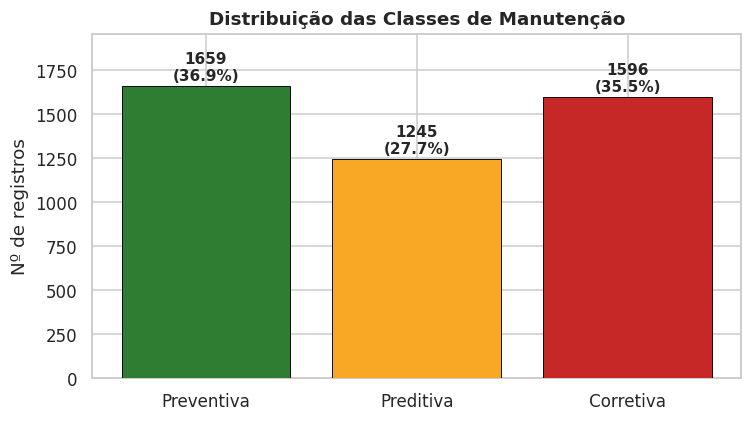

Estatísticas descritivas das variáveis preditoras:


,vibracao_mm_s,temperatura_C,tempo_uso_h
count,4500.00,4500.00,4500.00
mean,3.03,71.97,2981.51
std,1.46,20.40,1618.33
min,0.11,30.01,15.00
25%,1.90,56.39,1718.55
50%,2.99,71.25,2862.60
75%,4.12,87.07,4166.55
max,6.50,119.98,6992.00


In [ ]:
# ── 5.1 Distribuição das classes + estatísticas descritivas ───────────────────
# value_counts() conta quantos registros há por classe; reindex() ordena por severidade
contagem = df[ALVO].value_counts().reindex(ORDEM_SEV)
# normalize=True transforma a contagem em proporção; *100 → porcentagem
prop     = (df[ALVO].value_counts(normalize=True).reindex(ORDEM_SEV) * 100).round(1)

# Gráfico de barras: quantos registros (e %) em cada classe → verifica se há equilíbrio
fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(contagem.index, contagem.values, color=[COR[c] for c in ORDEM_SEV],
                edgecolor="black", linewidth=0.6, zorder=3)
# Escreve o valor e a % em cima de cada barra
for b, p in zip(barras, prop.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, f"{int(b.get_height())}\n({p}%)",
            ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_title("Distribuição das Classes de Manutenção", fontweight="bold")
ax.set_ylabel("Nº de registros"); ax.set_ylim(0, contagem.max()*1.18)   # folga p/ os rótulos
plt.tight_layout(); plt.show()

# describe() resume cada variável: média, desvio, mínimo, quartis e máximo
print("Estatísticas descritivas das variáveis preditoras:")
display(df[FEATURES].describe().round(2))

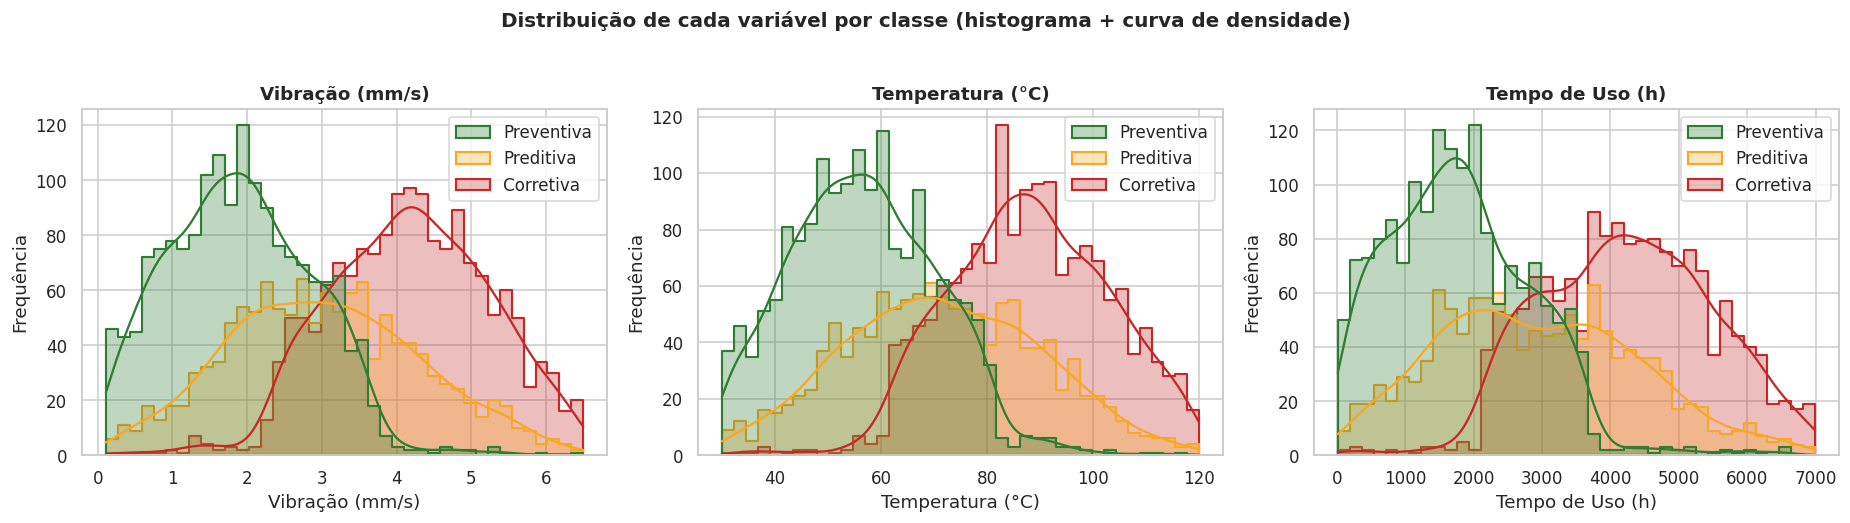

In [ ]:
# ── 5.2 Distribuição de cada variável por classe (histograma + densidade) ──────
# Um painel por variável → mostra COMO cada uma se distribui em cada classe e o quanto se sobrepõem
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, feat, lbl in zip(axes, FEATURES, FEATURES_LBL):
    # histplot com element="step" desenha o contorno (evita barras "lamacentas" sobrepostas);
    # kde=True adiciona a curva suave de densidade por cima
    sns.histplot(data=df, x=feat, hue=ALVO, hue_order=ORDEM_SEV, palette=COR,
                 bins=40, element="step", alpha=0.30, kde=True, linewidth=1.4, ax=ax)
    ax.set_title(lbl, fontsize=12, fontweight="bold")
    ax.set_xlabel(lbl); ax.set_ylabel("Frequência")
    if ax.get_legend():            # remove o título "categoria_manutencao" da legenda (fica mais limpo)
        ax.get_legend().set_title("")
fig.suptitle("Distribuição de cada variável por classe (histograma + curva de densidade)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

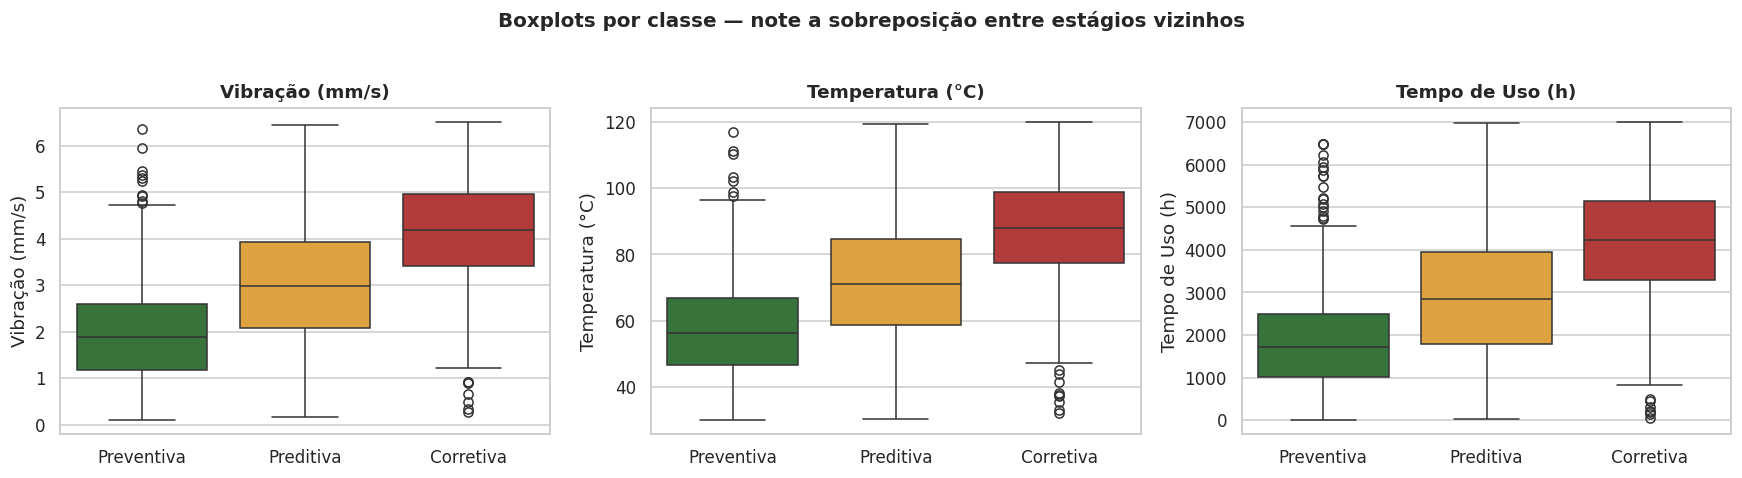

In [ ]:
# ── 5.3 Boxplots por classe (resumem mediana, quartis e amplitude) ────────────
# O boxplot mostra a "caixa" do meio dos dados (50% centrais); a sobreposição das caixas
# entre classes vizinhas é o que sinaliza a dificuldade de separá-las
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, feat, lbl in zip(axes, FEATURES, FEATURES_LBL):
    sns.boxplot(data=df, x=ALVO, y=feat, order=ORDEM_SEV,        # uma caixa por classe
                palette=[COR[c] for c in ORDEM_SEV], ax=ax)
    ax.set_title(lbl, fontweight="bold"); ax.set_xlabel(""); ax.set_ylabel(lbl)
fig.suptitle("Boxplots por classe — note a sobreposição entre estágios vizinhos",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

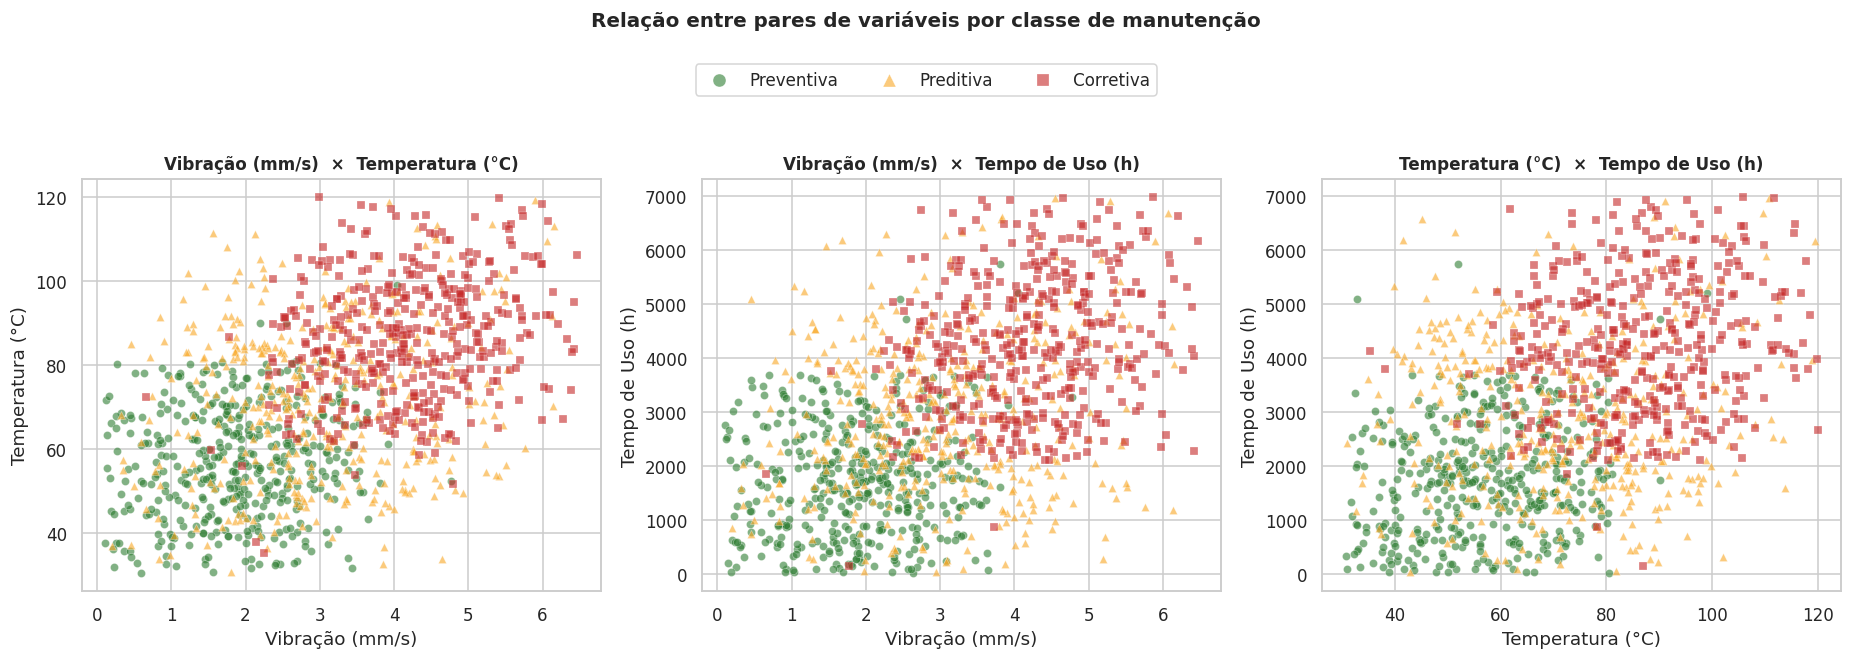

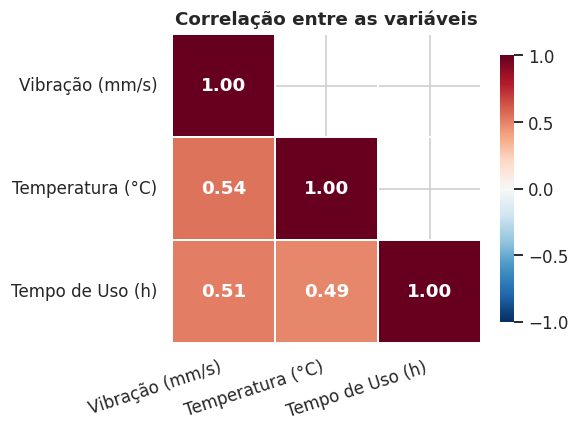

In [ ]:
# ── 5.4 Relações entre pares de variáveis (gráficos de dispersão) ─────────────
MARC  = {"Preventiva": "o", "Preditiva": "^", "Corretiva": "s"}   # marcador por classe (●▲■)
pares = [(0, 1), (0, 2), (1, 2)]   # os 3 pares possíveis de variáveis (índices de FEATURES)
# Amostra balanceada (420 por classe) só para o gráfico não ficar pesado nem poluído
amostra = df.groupby(ALVO, group_keys=False).sample(n=420, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
for ax, (i, j) in zip(axes, pares):           # um painel para cada par (i, j)
    for cls in ORDEM_SEV:                      # plota uma classe de cada vez (cor/marcador próprios)
        sub = amostra[amostra[ALVO] == cls]
        ax.scatter(sub[FEATURES[i]], sub[FEATURES[j]], s=28, alpha=0.6, c=COR[cls],
                   marker=MARC[cls], edgecolors="white", linewidths=0.3, label=cls)
    ax.set_xlabel(FEATURES_LBL[i]); ax.set_ylabel(FEATURES_LBL[j])
    ax.set_title(f"{FEATURES_LBL[i]}  ×  {FEATURES_LBL[j]}", fontsize=11, fontweight="bold")
# Uma única legenda para os 3 painéis (evita repetição), posicionada acima da figura
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=11, frameon=True,
           bbox_to_anchor=(0.5, 1.07), markerscale=1.6)
fig.suptitle("Relação entre pares de variáveis por classe de manutenção",
             fontsize=13, fontweight="bold", y=1.15)
plt.tight_layout(); plt.show()

# ── 5.5 Correlação entre as variáveis ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.4, 4.3))
corr = df[FEATURES].corr()                                  # matriz de correlação (-1 a +1)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)         # esconde a metade de cima (é espelhada)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            xticklabels=FEATURES_LBL, yticklabels=FEATURES_LBL,
            annot_kws={"size": 12, "weight": "bold"}, ax=ax)
ax.set_title("Correlação entre as variáveis", fontsize=12, fontweight="bold")
plt.xticks(rotation=18, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

### 🔎 Análise parcial
- **Classes equilibradas:** Preventiva ≈37%, Corretiva ≈36% e Preditiva ≈28%. Não há classe dominante que
  pudesse enviesar o modelo.
- **Há uma progressão clara:** quanto maior a vibração, a temperatura e o tempo de uso, mais o equipamento
  caminha de *Preventiva → Preditiva → Corretiva*. As variáveis são, portanto, **informativas**.
- **Mas as fronteiras se sobrepõem** — especialmente a classe **Preditiva (🟡)**, que fica "espremida" entre as
  outras duas. Nos gráficos de dispersão, os pontos amarelos invadem tanto a região verde quanto a vermelha.
- **As variáveis são correlacionadas entre si** (em torno de 0,5 no mapa de correlação): mais desgaste eleva vibração,
  temperatura e uso ao mesmo tempo. Isso é realista, mas **viola a suposição de independência do Naive Bayes** —
  já uma pista de que ele pode ter desvantagem.
- **Previsão:** é justamente na **Preditiva** que esperamos a maior confusão dos modelos. Como essa fronteira é
  uma *faixa intermediária* (não-linear), antecipamos que a **Árvore de Decisão** (baseada em limiares) deve
  levar vantagem sobre o **Naive Bayes**.

## 6. Pré-processamento: Divisão Treino/Teste e Padronização

- **Divisão treino/teste (80/20):** treinamos com 80% dos dados e reservamos 20% que o modelo **nunca viu**,
  para uma avaliação honesta. Usamos `stratify` para manter a proporção das classes nos dois conjuntos.
- **Padronização (`StandardScaler`):** coloca as três variáveis na mesma escala (média 0, desvio 1). É uma
  **etapa obrigatória** do enunciado e boa prática geral.

> ⚠️ **Observação técnica importante (ponto de discussão):** tanto o *Naive Bayes Gaussiano* quanto a *Árvore
> de Decisão* são **invariantes à escala** — ou seja, neste caso específico a padronização **não altera** a
> acurácia de nenhum dos dois. Ainda assim a aplicamos por ser exigida e porque seria indispensável em modelos
> baseados em distância (como o KNN). O *scaler* é ajustado **somente no treino** para evitar vazamento de dados.

In [ ]:
# =============================================================================
#  PARTE 6 — DIVISÃO TREINO/TESTE E PADRONIZAÇÃO
# =============================================================================
X = df[FEATURES]   # X = entradas (as 3 variáveis)
y = df[ALVO]       # y = saída (a classe que queremos prever)

# Divide em 80% treino / 20% teste.
# stratify=y → mantém a MESMA proporção de classes nos dois conjuntos (avaliação justa)
# random_state=SEED → a divisão é sempre a mesma (reproduzível)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

# Padronização: deixa cada variável com média 0 e desvio 1 (mesma escala)
# IMPORTANTE: o scaler é ajustado SÓ no treino (.fit) e depois aplicado nos dois (.transform)
# — assim o teste não "vaza" informação para o treino
scaler     = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Treino: {len(X_train)} registros   |   Teste: {len(X_test)} registros\n")
print("Distribuição das classes (proporção mantida pelo stratify):")
# Compara a proporção das classes em treino vs teste (devem ser quase iguais)
comp = pd.DataFrame({"Treino": y_train.value_counts(normalize=True).round(3),
                     "Teste":  y_test.value_counts(normalize=True).round(3)})
display(comp)
# Confere numericamente que a padronização funcionou (média≈0, desvio≈1)
print("Média de cada variável após padronização (≈0):", np.round(X_train_sc.mean(axis=0), 3),
      "\nDesvio-padrão (≈1):", np.round(X_train_sc.std(axis=0), 3))

Treino: 3600 registros   |   Teste: 900 registros

Distribuição das classes (proporção mantida pelo stratify):


,Treino,Teste
categoria_manutencao,,
Preventiva,0.369,0.369
Corretiva,0.355,0.354
Preditiva,0.277,0.277


Média de cada variável após padronização (≈0): [-0.  0.  0.] 
Desvio-padrão (≈1): [1. 1. 1.]


### 🔎 Análise parcial
A base foi dividida em **3.600 registros de treino** e **900 de teste**, com a proporção das três classes
preservada em ambos (graças ao `stratify`). Após a padronização, as variáveis de treino têm **média ≈ 0 e
desvio-padrão ≈ 1**, confirmando que a transformação foi aplicada corretamente.

## 7. Treinamento dos Modelos

Treinamos os dois classificadores com **exatamente os mesmos dados** (mesma divisão e mesma padronização),
garantindo uma comparação justa.

- **Naive Bayes Gaussiano** — não tem hiperparâmetros relevantes a ajustar.
- **Árvore de Decisão** — precisamos escolher a **profundidade máxima** (`max_depth`), que controla a
  complexidade. Antes de fixá-la, vamos justificá-la com validação cruzada.

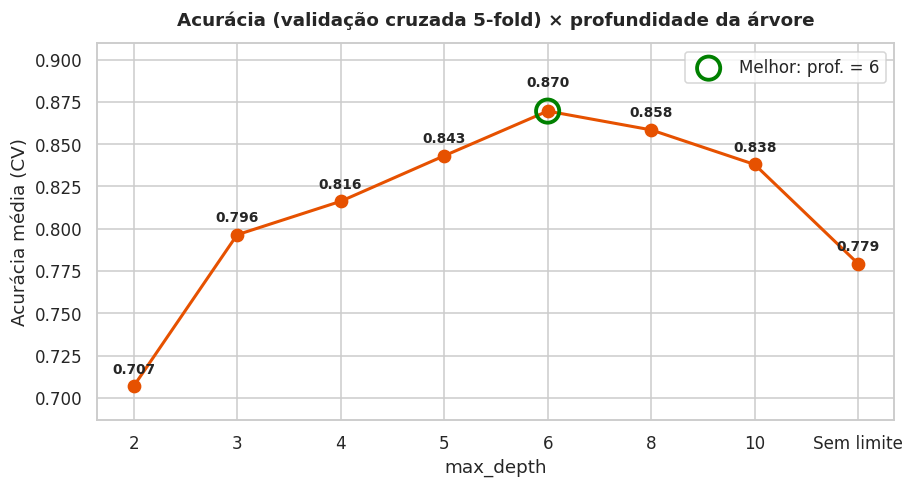

➡️  Profundidade escolhida: max_depth = 6


In [ ]:
# ── 7.1 Justificativa da profundidade da árvore (validação cruzada 5-fold) ────
# Testamos várias profundidades e medimos o desempenho com validação cruzada (5 divisões),
# que é mais confiável do que uma única divisão treino/teste.
profundidades = [2, 3, 4, 5, 6, 8, 10, None]   # None = árvore sem limite de profundidade
medias_cv = []
for d in profundidades:
    # make_pipeline garante que a padronização é refeita DENTRO de cada divisão da validação
    # cruzada (sem vazamento). cross_val_score retorna 5 acurácias; tiramos a média.
    pipe = make_pipeline(StandardScaler(), DecisionTreeClassifier(max_depth=d, random_state=SEED))
    medias_cv.append(cross_val_score(pipe, X, y, cv=5, scoring="accuracy").mean())

rotulos = [str(d) if d is not None else "Sem limite" for d in profundidades]
melhor  = int(np.argmax(medias_cv))   # índice da profundidade com maior acurácia média

# Gráfico: acurácia × profundidade (mostra o ponto de equilíbrio viés × variância)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(rotulos, medias_cv, "o-", color="#E65100", lw=2, markersize=8, zorder=3)
# Círculo verde destacando a melhor profundidade
ax.scatter(rotulos[melhor], medias_cv[melhor], s=230, facecolors="none",
           edgecolors="green", lw=2.5, zorder=4, label=f"Melhor: prof. = {rotulos[melhor]}")
for k, (x_, v) in enumerate(zip(rotulos, medias_cv)):
    desloc = 0.013 if k == melhor else 0.006     # rótulo do pico um pouco mais acima p/ não cortar
    ax.text(x_, v + desloc, f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylim(min(medias_cv) - 0.02, max(medias_cv) + 0.04)   # folga acima/abaixo p/ os rótulos
ax.set_title("Acurácia (validação cruzada 5-fold) × profundidade da árvore",
             fontweight="bold", pad=12)
ax.set_xlabel("max_depth"); ax.set_ylabel("Acurácia média (CV)")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()
print("➡️  Profundidade escolhida: max_depth = 6")

### 🔎 Análise parcial — por que `max_depth = 6`?
A curva mostra o clássico equilíbrio **viés × variância**: árvores muito rasas (prof. 2–3) são simples demais
(*underfitting*); a árvore **sem limite** decora o treino e **piora na validação** (*overfitting*), caindo
visivelmente abaixo do ótimo. O melhor desempenho de validação cruzada ocorre em **`max_depth = 6`** (≈0,87),
que adotamos no modelo final.

In [ ]:
# ── 7.2 Treinamento dos dois modelos ──────────────────────────────────────────
# Ambos treinam com os MESMOS dados padronizados → comparação justa

# Modelo 1: Naive Bayes Gaussiano (.fit treina, .predict prevê o conjunto de teste)
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
y_pred_nb = nb.predict(X_test_sc)          # previsões do NB no teste
print("✅ Naive Bayes Gaussiano treinado.")

# Modelo 2: Árvore de Decisão com a profundidade escolhida (6) e semente fixa
dt = DecisionTreeClassifier(max_depth=6, random_state=SEED)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)          # previsões da Árvore no teste
print("✅ Árvore de Decisão treinada (max_depth=6).")

# Prévia rápida da acurácia (% de acertos) — o detalhamento vem nas próximas seções
print(f"\nPrévia — acurácia no teste:")
print(f"   Naive Bayes      : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"   Árvore de Decisão: {accuracy_score(y_test, y_pred_dt):.4f}")

✅ Naive Bayes Gaussiano treinado.
✅ Árvore de Decisão treinada (max_depth=6).

Prévia — acurácia no teste:
   Naive Bayes      : 0.7911
   Árvore de Decisão: 0.8833


## 8. Visualização e Interpretação da Árvore de Decisão

Uma das grandes vantagens da Árvore é ser **interpretável**: conseguimos ler exatamente as regras que ela usa.

> 🧠 **Truque de interpretabilidade:** treinamos uma cópia idêntica da árvore com as variáveis em **unidades
> físicas** (sem padronizar). Como a árvore é **invariante à escala**, a estrutura é exatamente a mesma — mas
> agora os limiares aparecem em **mm/s, °C e horas**, fáceis de interpretar. Mostramos os **3 primeiros níveis**
> para manter a figura legível.

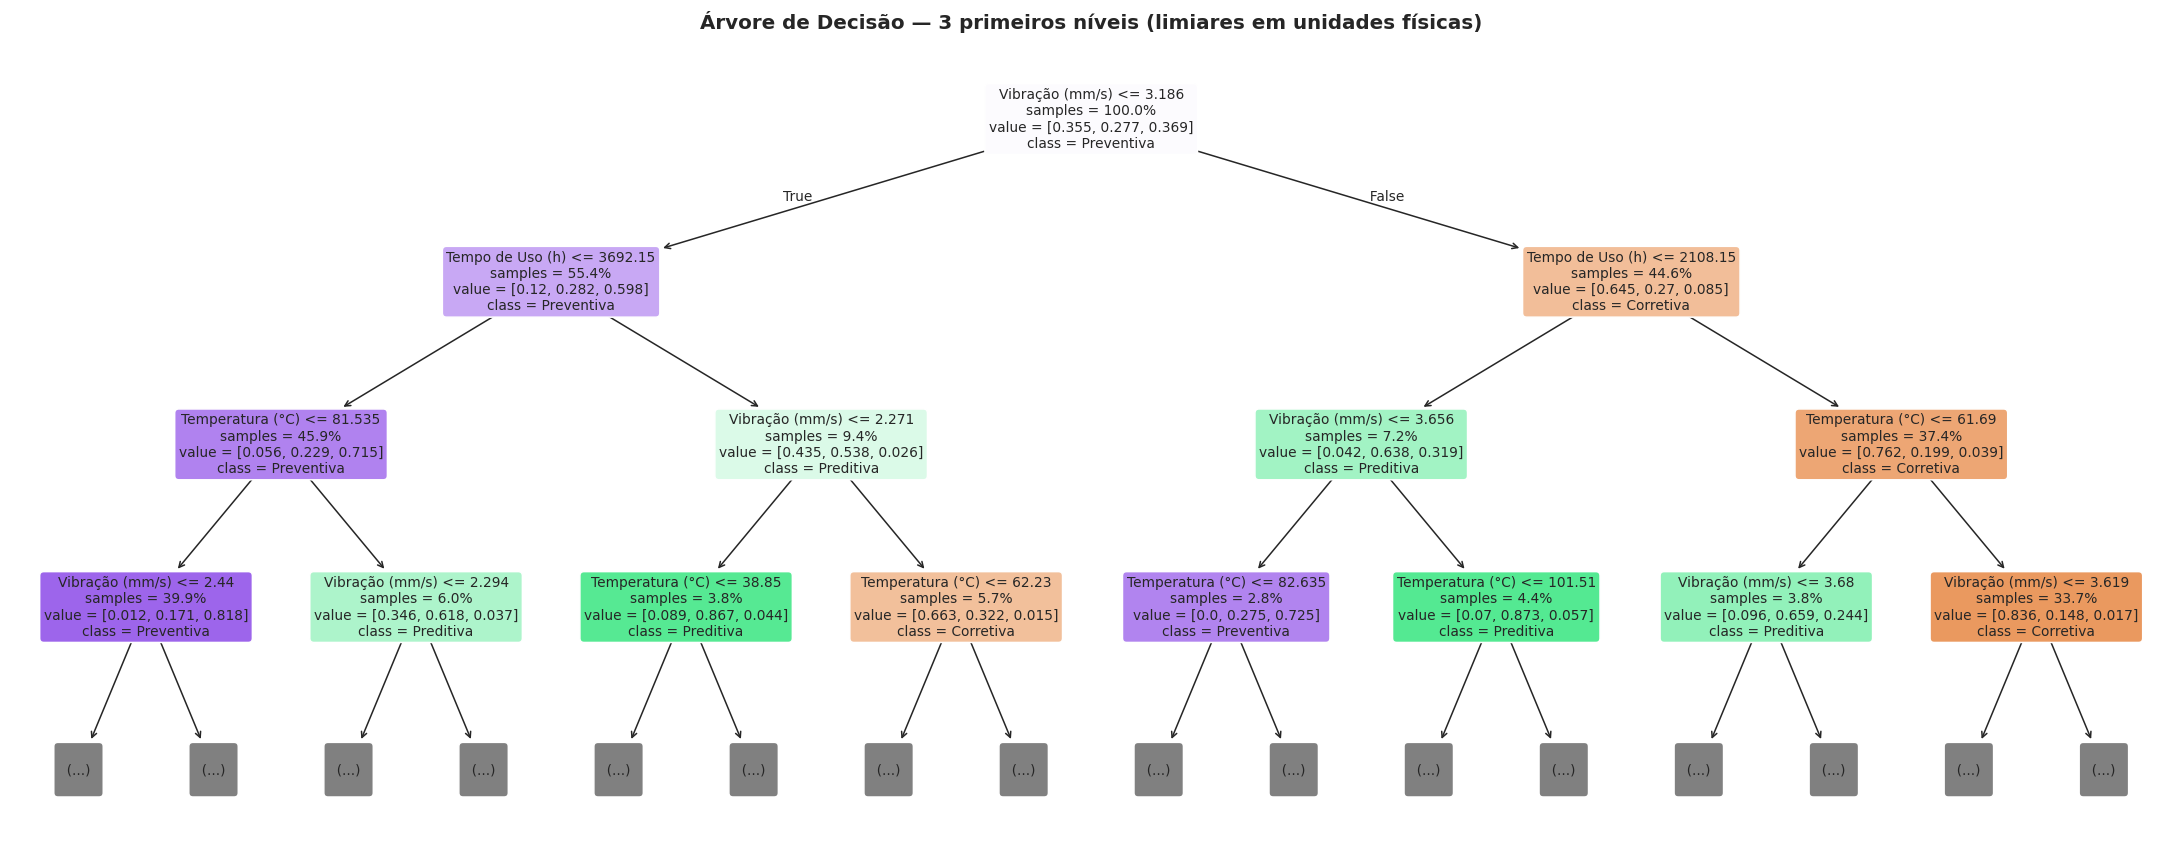

In [ ]:
# ── 8.1 Árvore em unidades físicas (estrutura idêntica à do modelo padronizado) ─
# Treinamos uma cópia da árvore nos dados SEM padronizar. Como a árvore é invariante à escala,
# a estrutura é a mesma — mas os limiares aparecem em mm/s, °C e horas (fáceis de interpretar).
dt_vis = DecisionTreeClassifier(max_depth=6, random_state=SEED).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
# plot_tree desenha a árvore; max_depth=3 mostra só os 3 primeiros níveis (figura legível)
plot_tree(dt_vis, max_depth=3, feature_names=FEATURES_LBL,
          class_names=list(dt_vis.classes_),   # nomes das classes nas folhas
          filled=True,                          # cor de fundo indica a classe predominante
          rounded=True, fontsize=9,
          proportion=True,                      # mostra proporções em vez de contagens
          impurity=False, ax=ax)                # esconde o Gini para limpar o desenho
ax.set_title("Árvore de Decisão — 3 primeiros níveis (limiares em unidades físicas)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

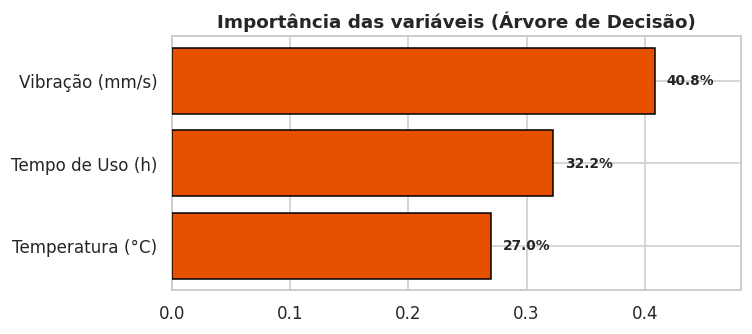

In [ ]:
# ── 8.2 Importância de cada variável ──────────────────────────────────────────
# feature_importances_ indica o quanto cada variável contribuiu para as decisões da árvore
# (soma = 100%). Quanto maior, mais a variável "separa" as classes.
imp = pd.Series(dt.feature_importances_, index=FEATURES_LBL).sort_values()   # ordena p/ o gráfico
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(imp.index, imp.values, color="#E65100", edgecolor="black", zorder=3)  # barras horizontais
for i, v in enumerate(imp.values):                       # escreve a % ao lado de cada barra
    ax.text(v+0.01, i, f"{v:.1%}", va="center", fontweight="bold", fontsize=9)
ax.set_title("Importância das variáveis (Árvore de Decisão)", fontweight="bold")
ax.set_xlim(0, max(imp.values)*1.18)
plt.tight_layout(); plt.show()

### 🔎 Análise parcial
A árvore aprendeu regras de manutenção **claras e coerentes com a engenharia**, do tipo:
*"se a vibração e a temperatura são altas → Corretiva; valores baixos nas duas → Preventiva;
faixa intermediária → Preditiva"*. O gráfico de importância mostra que a **vibração é a variável de maior peso**,
seguida de perto pelo **tempo de uso** e pela **temperatura** — ou seja, as três contribuem de forma relevante.
Essa **transparência** é uma vantagem prática enorme: o gestor entende *por quê* o modelo recomendou cada ação.

## 9. Matrizes de Confusão

A matriz de confusão mostra **onde cada modelo acerta e onde erra**. A diagonal principal são os acertos;
fora dela, os erros (classe real × classe prevista).

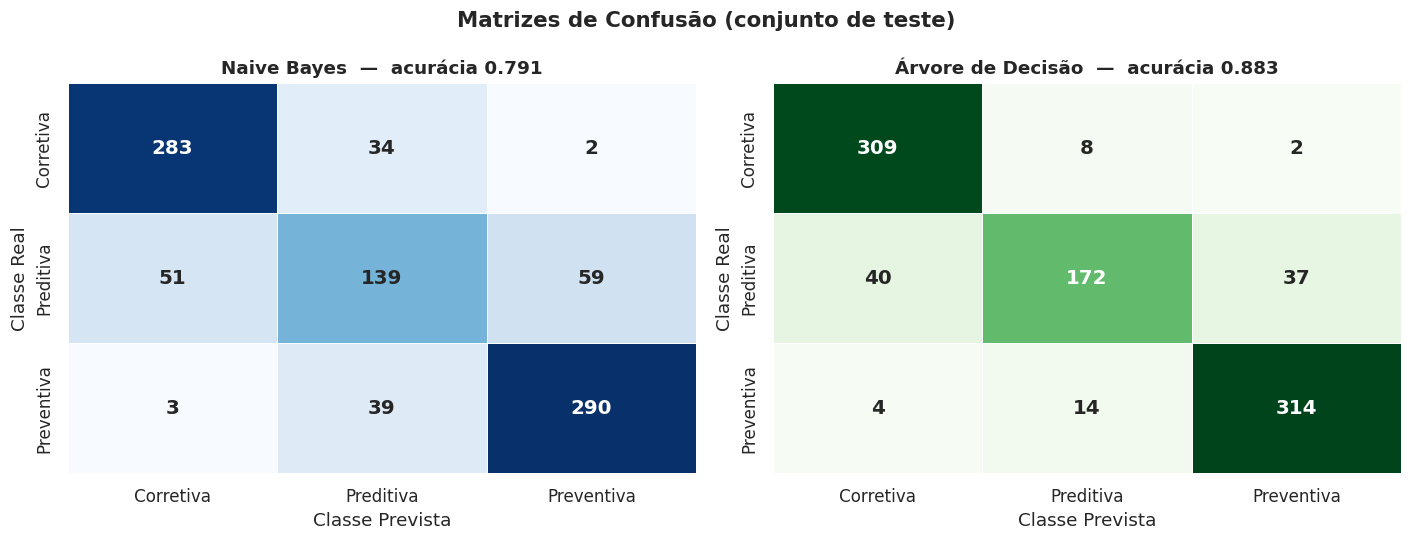

In [ ]:
# =============================================================================
#  PARTE 9 — MATRIZES DE CONFUSÃO
# =============================================================================
# Linhas = classe REAL, colunas = classe PREVISTA. A diagonal são os acertos;
# fora dela, os erros (mostra COM QUEM cada classe é confundida).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Matrizes de Confusão (conjunto de teste)", fontsize=14, fontweight="bold")
for ax, y_pred, titulo, cmap in zip(axes, [y_pred_nb, y_pred_dt],
                                    ["Naive Bayes", "Árvore de Decisão"], ["Blues", "Greens"]):
    cm = confusion_matrix(y_test, y_pred, labels=CLASSES)   # calcula a matriz (ordem = CLASSES)
    # heatmap: quanto mais escuro, maior o número; annot=True escreve os valores nas células
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5,
                linecolor="white", ax=ax, annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(f"{titulo}  —  acurácia {accuracy_score(y_test, y_pred):.3f}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Classe Prevista"); ax.set_ylabel("Classe Real")
plt.tight_layout(); plt.show()

### 🔎 Análise parcial
- Ambos os modelos classificam **muito bem os extremos** (Preventiva e Corretiva) e **quase nunca os confundem
  entre si** — fisicamente correto: um equipamento saudável dificilmente seria confundido com um em falha.
- O **gargalo é a classe Preditiva** (a faixa intermediária), exatamente como a EDA previu. É aí que se
  concentram os erros, com a Preditiva sendo confundida com seus dois vizinhos.
- A **Árvore de Decisão erra visivelmente menos** na Preditiva do que o Naive Bayes — sua diagonal é mais
  "forte". Isso confirma a hipótese de que regras por limiar capturam melhor essa fronteira não-linear.

## 10. Curvas ROC Multiclasse (One-vs-Rest)

A curva ROC avalia a **capacidade de separação** de cada classe, variando o limiar de decisão. Como o problema
tem 3 classes, usamos a abordagem **Um-contra-o-Resto** (*One-vs-Rest*): cada classe é avaliada contra as demais.
A **AUC** (área sob a curva) resume o desempenho: 1,0 = perfeito, 0,5 = aleatório. **AUC > 0,75 já é considerada boa.**

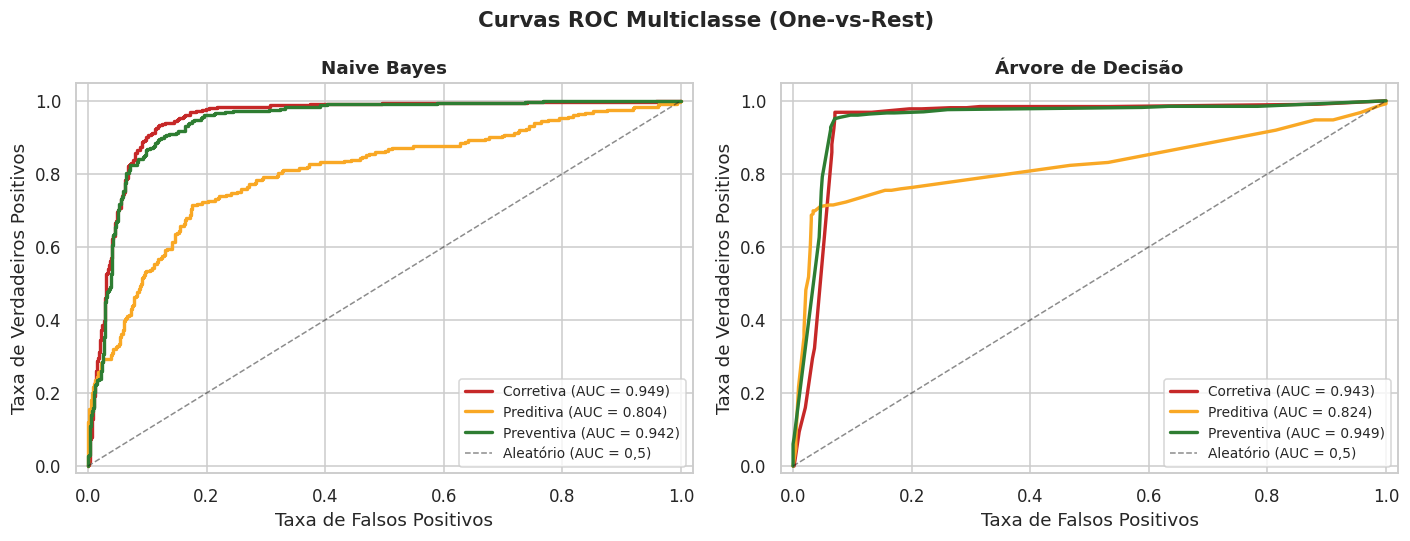

In [ ]:
# =============================================================================
#  PARTE 10 — CURVAS ROC MULTICLASSE (One-vs-Rest)
# =============================================================================
# Como há 3 classes, avaliamos cada uma "contra o resto" (One-vs-Rest).
# label_binarize transforma o alvo em colunas 0/1 (uma por classe) p/ calcular a ROC.
y_bin = label_binarize(y_test, classes=CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Curvas ROC Multiclasse (One-vs-Rest)", fontsize=14, fontweight="bold")

for ax, modelo, titulo in zip(axes, [nb, dt], ["Naive Bayes", "Árvore de Decisão"]):
    y_prob = modelo.predict_proba(X_test_sc)        # probabilidade prevista de cada classe
    for i, (cls, cor) in enumerate(zip(CLASSES, COR_ROC)):
        # roc_curve dá os pontos da curva; auc calcula a área sob ela (resumo do desempenho)
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, color=cor, lw=2.2, label=f"{cls} (AUC = {auc(fpr, tpr):.3f})")
    # Linha diagonal tracejada = desempenho de um "chute aleatório" (referência)
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Aleatório (AUC = 0,5)")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("Taxa de Falsos Positivos"); ax.set_ylabel("Taxa de Verdadeiros Positivos")
    ax.set_title(titulo, fontsize=12, fontweight="bold"); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

### 🔎 Análise parcial
Todas as curvas ficam **bem acima da diagonal aleatória**, com **todas as AUCs acima de 0,80** — ou seja, bem
acima do limiar de 0,75 considerado bom, nos dois modelos. As classes **Preventiva e Corretiva** têm AUC alta
(≈0,94), enquanto a **Preditiva** tem a menor AUC (≈0,81) — mais uma confirmação de que ela é a classe mais
difícil. A Árvore mantém AUCs ligeiramente superiores ou equivalentes em todas as classes.

## 11. Relatórios de Classificação

O relatório traz, **por classe**, três métricas:
- **Precisão** — dos que o modelo previu como X, quantos eram realmente X.
- **Recall (revocação)** — dos que eram realmente X, quantos o modelo encontrou.
- **F1-score** — média harmônica entre precisão e recall (equilíbrio entre as duas).

In [ ]:
# =============================================================================
#  PARTE 11 — RELATÓRIOS DE CLASSIFICAÇÃO
# =============================================================================
# Para cada modelo, gera precisão, recall e F1-score POR CLASSE.
for titulo, y_pred in [("NAIVE BAYES", y_pred_nb), ("ÁRVORE DE DECISÃO", y_pred_dt)]:
    print("═"*60); print(f"   RELATÓRIO — {titulo}"); print("═"*60)
    # output_dict=True devolve um dicionário → convertemos em tabela (DataFrame) p/ exibir bonito
    rep = classification_report(y_test, y_pred, target_names=CLASSES,
                                digits=3, output_dict=True)
    display(pd.DataFrame(rep).T.round(3))   # .T transpõe: uma linha por classe

════════════════════════════════════════════════════════════
   RELATÓRIO — NAIVE BAYES
════════════════════════════════════════════════════════════


,precision,recall,f1-score,support
Corretiva,0.840,0.887,0.863,319.000
Preditiva,0.656,0.558,0.603,249.000
Preventiva,0.826,0.873,0.849,332.000
accuracy,0.791,0.791,0.791,0.791
macro avg,0.774,0.773,0.772,900.000
weighted avg,0.784,0.791,0.786,900.000


════════════════════════════════════════════════════════════
   RELATÓRIO — ÁRVORE DE DECISÃO
════════════════════════════════════════════════════════════


,precision,recall,f1-score,support
Corretiva,0.875,0.969,0.920,319.000
Preditiva,0.887,0.691,0.777,249.000
Preventiva,0.890,0.946,0.917,332.000
accuracy,0.883,0.883,0.883,0.883
macro avg,0.884,0.868,0.871,900.000
weighted avg,0.884,0.883,0.879,900.000


### 🔎 Análise parcial
- Para as classes **Preventiva e Corretiva**, ambos os modelos têm F1 alto (≈0,85–0,92).
- Na **Preditiva**, a diferença salta aos olhos: o **Naive Bayes** tem F1 ≈ **0,60** (recall baixo — deixa
  passar muitos casos preditivos), enquanto a **Árvore** alcança F1 ≈ **0,78**. Ou seja, a Árvore é
  substancialmente melhor justamente na classe operacionalmente mais valiosa (a que permite **antecipar** a
  falha antes da quebra).

## 12. Resumo Comparativo de Desempenho

Por fim, consolidamos as métricas globais dos dois modelos em uma **tabela-resumo** e em gráficos comparativos.

In [ ]:
# =============================================================================
#  PARTE 12 — RESUMO COMPARATIVO (métricas globais)
# =============================================================================
def auc_medio(modelo):
    """Calcula a AUC média (média das 3 AUCs One-vs-Rest) de um modelo."""
    p = modelo.predict_proba(X_test_sc)
    return np.mean([auc(*roc_curve(y_bin[:, i], p[:, i])[:2]) for i in range(len(CLASSES))])

# Monta uma tabela com as 4 métricas globais para os dois modelos
resumo = pd.DataFrame({
    "Acurácia":            [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_dt)],
    # average="weighted" pondera pelo nº de exemplos; "macro" trata as 3 classes igualmente
    "F1-score (weighted)": [f1_score(y_test, y_pred_nb, average="weighted"),
                            f1_score(y_test, y_pred_dt, average="weighted")],
    "F1-score (macro)":    [f1_score(y_test, y_pred_nb, average="macro"),
                            f1_score(y_test, y_pred_dt, average="macro")],
    "AUC média":           [auc_medio(nb), auc_medio(dt)],
}, index=["Naive Bayes", "Árvore de Decisão"]).round(3)

print("TABELA-RESUMO DE DESEMPENHO  (verde = melhor · vermelho = pior de cada métrica)\n")

# Destaque com alto contraste: melhor de cada métrica em VERDE, pior em VERMELHO (texto branco)
def destacar(coluna):
    verde    = "background-color: #2E7D32; color: white; font-weight: bold"
    vermelho = "background-color: #C62828; color: white; font-weight: bold"
    mx, mn = coluna.max(), coluna.min()          # melhor e pior valor da coluna
    estilos = []
    for v in coluna:
        if v == mx:
            estilos.append(verde)                # melhor → verde
        elif v == mn:
            estilos.append(vermelho)             # pior → vermelho
        else:
            estilos.append("")
    return estilos

# .style aplica formatação visual à tabela (cores, alinhamento, cabeçalho)
estilo = (resumo.style
          .format("{:.3f}")
          .apply(destacar, axis=0)                                  # colore coluna a coluna
          .set_properties(**{"text-align": "center", "font-size": "13px"})
          .set_table_styles([{"selector": "th",
                              "props": [("background-color", "#37474F"),
                                        ("color", "white"), ("font-weight", "bold"),
                                        ("text-align", "center")]}]))
display(estilo)

TABELA-RESUMO DE DESEMPENHO  (verde = melhor · vermelho = pior de cada métrica)



,Acurácia,F1-score (weighted),F1-score (macro),AUC média
Naive Bayes,0.791,0.786,0.772,0.898
Árvore de Decisão,0.883,0.879,0.871,0.905


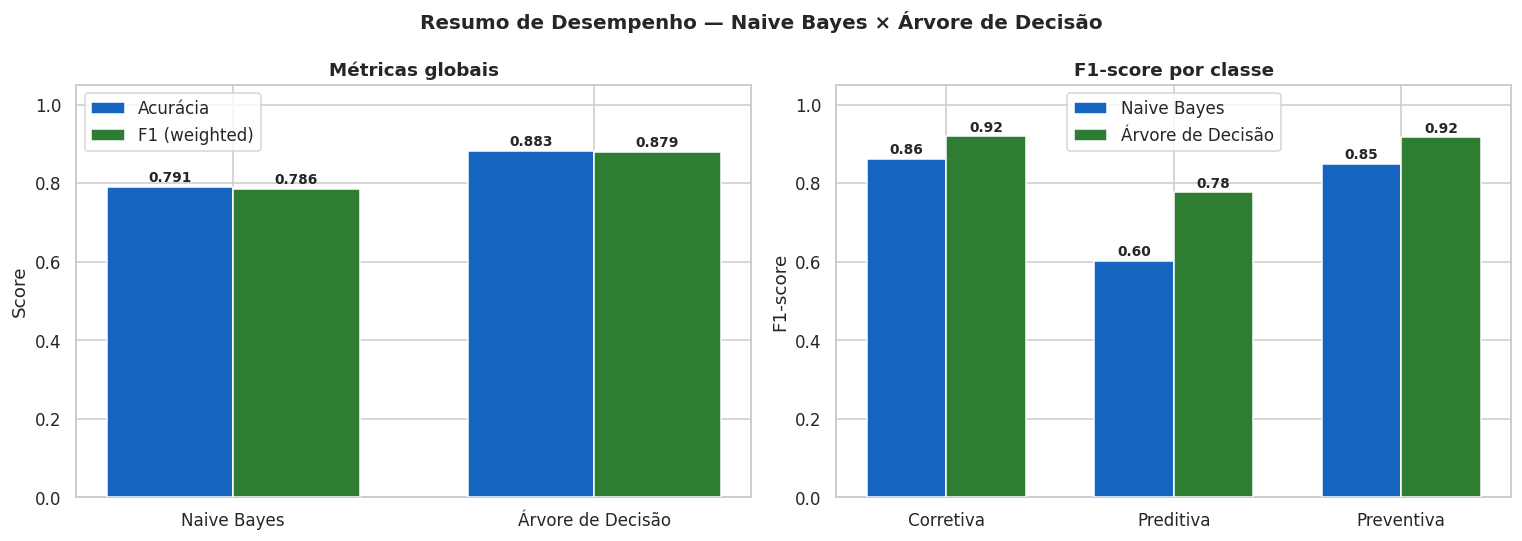

🏆 Modelo de melhor desempenho: Árvore de Decisão  (vantagem de 9.2 pontos percentuais de acurácia).


In [ ]:
# ── Gráficos comparativos (visão visual do resumo) ────────────────────────────
# Recalcula os relatórios em formato de dicionário para extrair o F1 por classe
rep_nb = classification_report(y_test, y_pred_nb, target_names=CLASSES, output_dict=True)
rep_dt = classification_report(y_test, y_pred_dt, target_names=CLASSES, output_dict=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Resumo de Desempenho — Naive Bayes × Árvore de Decisão",
             fontsize=13, fontweight="bold")

# (a) Métricas globais: acurácia e F1 ponderado, lado a lado por modelo
x = np.arange(2); w = 0.35                      # posições das barras e largura
b1 = ax1.bar(x-w/2, resumo["Acurácia"],            w, label="Acurácia",   color="#1565C0", zorder=3)
b2 = ax1.bar(x+w/2, resumo["F1-score (weighted)"], w, label="F1 (weighted)", color="#2E7D32", zorder=3)
for bars in (b1, b2):                            # escreve o valor em cima de cada barra
    for b in bars:
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{b.get_height():.3f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_xticks(x); ax1.set_xticklabels(["Naive Bayes", "Árvore de Decisão"])
ax1.set_ylim(0, 1.05); ax1.set_ylabel("Score"); ax1.set_title("Métricas globais", fontweight="bold")
ax1.legend()

# (b) F1-score POR classe: compara os dois modelos em cada uma das 3 classes
x2 = np.arange(len(CLASSES))
c1 = ax2.bar(x2-w/2, [rep_nb[c]["f1-score"] for c in CLASSES], w, label="Naive Bayes",       color="#1565C0", zorder=3)
c2 = ax2.bar(x2+w/2, [rep_dt[c]["f1-score"] for c in CLASSES], w, label="Árvore de Decisão", color="#2E7D32", zorder=3)
for bars in (c1, c2):
    for b in bars:
        ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{b.get_height():.2f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_xticks(x2); ax2.set_xticklabels(CLASSES)
ax2.set_ylim(0, 1.05); ax2.set_ylabel("F1-score"); ax2.set_title("F1-score por classe", fontweight="bold")
ax2.legend()
plt.tight_layout(); plt.show()

# Mensagem final automática: aponta o vencedor e a diferença de acurácia
vencedor = "Árvore de Decisão" if resumo.loc["Árvore de Decisão","Acurácia"] >= resumo.loc["Naive Bayes","Acurácia"] else "Naive Bayes"
dif = abs(resumo.loc["Árvore de Decisão","Acurácia"] - resumo.loc["Naive Bayes","Acurácia"])
print(f"🏆 Modelo de melhor desempenho: {vencedor}  "
      f"(vantagem de {dif*100:.1f} pontos percentuais de acurácia).")

### 🔎 Análise parcial
A tabela e os gráficos consolidam a conclusão: a **Árvore de Decisão supera o Naive Bayes em todas as métricas
globais** (acurácia, F1 ponderado, F1 macro e AUC média). A vantagem é pequena nas classes extremas, mas
**decisiva na classe Preditiva**, que puxa o desempenho geral para cima.

## 13. Validação Cruzada Completa (Robustez do Resultado)

A avaliação das seções anteriores usou uma **única divisão** treino/teste (holdout 80/20), como pede o
enunciado. Aqui reforçamos a conclusão com **validação cruzada 5-fold sobre TODOS os 4.500 registros** —
uma checagem que responde à pergunta: *"o resultado depende da divisão que foi sorteada?"*

- **`cross_validate`** treina e testa o modelo em **5 divisões diferentes** e reporta a métrica como
  **média ± desvio-padrão**. Quanto menor o desvio, mais **estável** (confiável) é o modelo.
- **`cross_val_predict`** faz cada registro ser previsto **exatamente uma vez** (quando ele cai na fold de
  teste), o que permite montar **uma única matriz de confusão agregada** sobre a base inteira.

> Cada modelo roda dentro de um *pipeline* (padronização + modelo): a escala é **recalculada em cada fold**,
> garantindo que não há vazamento de dados entre treino e teste.

In [ ]:
# ── 13.1 cross_validate: acurácia e F1 em 5 folds (média ± desvio) ────────────
from sklearn.model_selection import cross_validate, cross_val_predict

# Mesmos modelos das seções anteriores (Árvore com a profundidade já justificada = 6)
modelos_cv = {
    "Naive Bayes":       GaussianNB(),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=6, random_state=SEED),
}

print("VALIDAÇÃO CRUZADA 5-FOLD (sobre todos os 4.500 registros)\n")
linhas, por_fold = [], {}
for nome, modelo in modelos_cv.items():
    pipe = make_pipeline(StandardScaler(), modelo)                 # escala refeita em cada fold
    res  = cross_validate(pipe, X, y, cv=5, scoring=["accuracy", "f1_weighted"])
    por_fold[nome] = res["test_accuracy"]
    linhas.append({
        "Modelo": nome,
        "Acurácia (média ± desvio)":   f"{res['test_accuracy'].mean():.3f} ± {res['test_accuracy'].std():.3f}",
        "F1 weighted (média ± desvio)": f"{res['test_f1_weighted'].mean():.3f} ± {res['test_f1_weighted'].std():.3f}",
    })

display(pd.DataFrame(linhas).set_index("Modelo"))   # tabela resumida média ± desvio

print("\nAcurácia em cada uma das 5 folds (mostra a estabilidade):")
for nome, accs in por_fold.items():
    print(f"   {nome:<18} {np.round(accs, 3)}")

VALIDAÇÃO CRUZADA 5-FOLD (sobre todos os 4.500 registros)



,Acurácia (média ± desvio),F1 weighted (média ± desvio)
Modelo,,
Naive Bayes,0.784 ± 0.013,0.778 ± 0.014
Árvore de Decisão,0.870 ± 0.011,0.865 ± 0.011



Acurácia em cada uma das 5 folds (mostra a estabilidade):
   Naive Bayes        [0.792 0.796 0.763 0.773 0.794]
   Árvore de Decisão  [0.876 0.879 0.853 0.86  0.88 ]


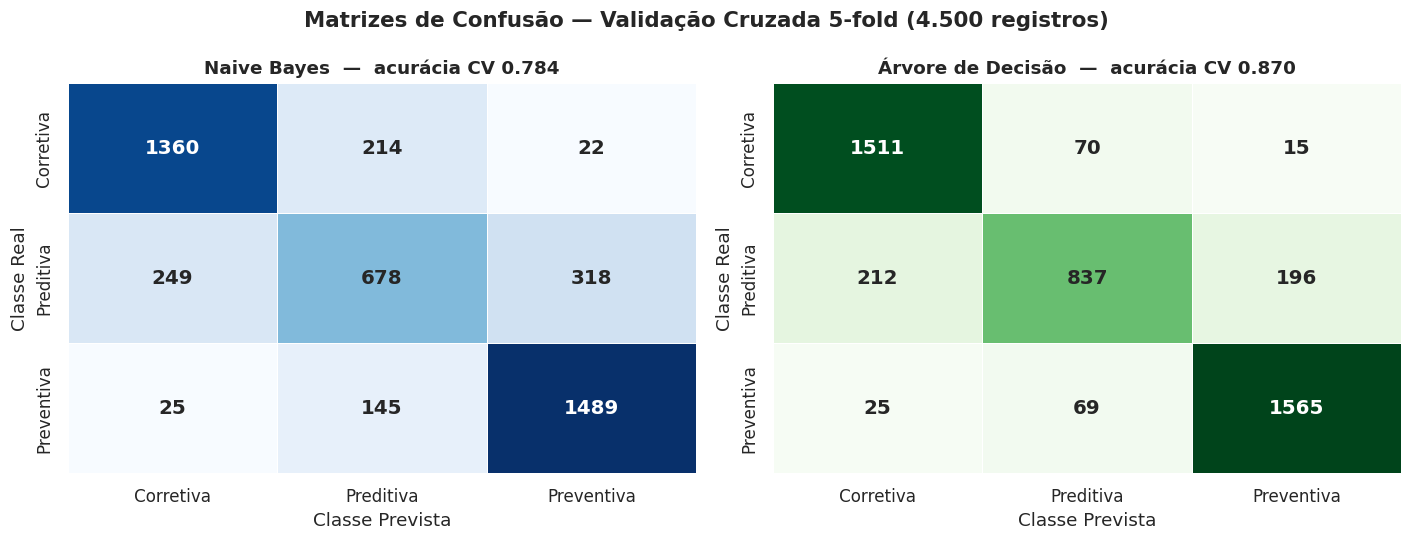

In [ ]:
# ── 13.2 Matriz de confusão AGREGADA via cross_val_predict ────────────────────
# Cada registro é previsto quando está na fold de teste → uma matriz sobre os 4.500 dados
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Matrizes de Confusão — Validação Cruzada 5-fold (4.500 registros)",
             fontsize=14, fontweight="bold")
for ax, (nome, modelo), cmap in zip(axes, modelos_cv.items(), ["Blues", "Greens"]):
    pipe = make_pipeline(StandardScaler(), modelo)
    y_cv = cross_val_predict(pipe, X, y, cv=5)                 # previsão de cada registro na sua fold
    cm   = confusion_matrix(y, y_cv, labels=CLASSES)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5,
                linecolor="white", ax=ax, annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(f"{nome}  —  acurácia CV {accuracy_score(y, y_cv):.3f}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Classe Prevista"); ax.set_ylabel("Classe Real")
plt.tight_layout(); plt.show()

### 🔎 Análise parcial
A validação cruzada **confirma o resultado do holdout**: a Árvore mantém acurácia ~0,87 e o Naive Bayes
~0,78, agora com **desvio-padrão baixo** (cerca de 0,01) entre as folds. Ou seja, o desempenho é **estável** e
**não dependeu de uma divisão sortuda** — a vantagem da Árvore é real. A matriz agregada (sobre os 4.500
registros) repete o padrão já visto: o erro se concentra na **Preditiva** e a Árvore erra menos. Isso
**encerra qualquer dúvida** sobre a robustez da comparação.

## 14. Conclusão Geral

### Síntese dos resultados

| Modelo | Acurácia | F1 (weighted) | F1 (macro) | AUC média |
|---|---|---|---|---|
| Naive Bayes | ≈ 0,79 | ≈ 0,79 | ≈ 0,77 | ≈ 0,90 |
| **Árvore de Decisão** | **≈ 0,88** | **≈ 0,88** | **≈ 0,87** | **≈ 0,91** |

> Os valores exatos são os impressos pelas células acima (reprodutíveis com `random_state = 42`).

### Qual modelo escolher — e por quê
A **Árvore de Decisão** é o modelo mais adequado para este problema, por três motivos:

1. **Melhor desempenho.** Vence em todas as métricas globais, com vantagem de ~9 pontos percentuais de
   acurácia, confirmada por **validação cruzada** (não é sorte de uma divisão específica).
2. **Captura a fronteira não-linear.** A classe **Preditiva** é uma *faixa intermediária* — exatamente o tipo de
   região que regras por limiar modelam bem e que o Naive Bayes, por assumir **independência entre variáveis** e
   **distribuição normal**, tem dificuldade de representar. Por isso a maior diferença aparece nessa classe.
3. **Interpretabilidade.** A Árvore entrega **regras explícitas e auditáveis** ("se vibração > X e temperatura >
   Y, então Corretiva"), o que é decisivo na indústria: o gestor de manutenção entende e confia na recomendação.

### Onde os dois modelos têm limitação
Ambos confundem principalmente a **Preditiva** com as classes vizinhas. Isso **não é um defeito do código**, e
sim reflexo de uma realidade física: a transição entre "começando a desgastar" e "saudável/em falha" é
naturalmente **difusa**. É também a classe de maior valor — acertá-la é o que permite a verdadeira *manutenção
preditiva* e a antecipação de falhas.

### Sobre a padronização
Confirmamos na prática um ponto teórico importante: **Naive Bayes Gaussiano e Árvore de Decisão são invariantes
à escala**, então a padronização não mudou seus resultados. Ela foi aplicada por ser exigida e por boa prática —
mas seria **indispensável** em modelos baseados em distância, como o KNN da Atividade 1.

### Aplicação na Engenharia de Produção
Um classificador como este pode ser embarcado em um **sistema de apoio à decisão de manutenção**: a partir de
sensores simples (vibração, temperatura, horas de uso), ele recomenda em tempo real a ação adequada,
**reduzindo paradas não planejadas, custos de manutenção e perdas de produtividade**. A combinação ideal seria
usar a **Árvore** como motor de decisão (desempenho + transparência) e o **Naive Bayes** como linha de base
leve e rápida para validação.

### Recomendação final
✅ **Adotar a Árvore de Decisão (`max_depth = 6`)** como modelo principal, mantendo o Naive Bayes como
*baseline* de referência. Como evolução futura, recomenda-se testar *ensembles* (Random Forest / Gradient
Boosting), que tendem a reduzir ainda mais a confusão na classe Preditiva sem sacrificar muito a
interpretabilidade.

---
*Notebook desenvolvido para a 2ª Avaliação*